<a href="https://colab.research.google.com/github/ValeriaZav26/books-web-scraping-analysis/blob/main/Web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌐 Web Scraping: Сбор данных о книгах

В этом разделе мы собираем данные с сайта:

http://books.toscrape.com/

Этот сайт представляет собой **демонстрационный интернет-магазин книг**, специально созданный для практики **web scraping**.  
Он содержит информацию примерно о **1000 книгах**, включая их **названия, цены и рейтинги**.

**Web scraping** — это метод, который позволяет **автоматически извлекать данные с веб-сайтов** и преобразовывать их в структурированный формат (например, таблицу или датасет) для дальнейшего анализа.

С помощью библиотек Python **Requests** и **BeautifulSoup** мы будем:

- отправлять HTTP-запросы к сайту
- анализировать HTML-структуру страницы
- извлекать необходимую информацию о каждой книге
- сохранять собранные данные для дальнейшего анализа

Поскольку сайт содержит несколько страниц, скрипт будет **последовательно проходить по всем страницам**, чтобы собрать полный набор данных.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

In [2]:
url = "http://books.toscrape.com/"

response = requests.get(url)  # отправляем запрос к сайту и получаем HTML страницы

soup = BeautifulSoup(response.text, "html.parser") # преобразуем HTML код страницы в удобную структуру для поиска элементов

books = soup.find_all("article", class_="product_pod")  # находим все карточки книг на странице


In [3]:
data = []

for book in books:
    title = book.find("h3").find("a")["title"]   # извлекаем название книги из HTML структуры


    price = book.find("p", class_="price_color").text
    price = float(price.replace("£", "").replace("Â", ""))  # удаляем символ валюты и преобразуем цену в число
    rating_class = book.find("p", class_="star-rating")["class"][1]  # рейтинг книги хранится в классе HTML (например: Three, Four)

    link = book.find("a")["href"]

    data.append({
        "title": title,
        "price": price,
        "rating": rating_class,
        "link": link
    })   # добавляем информацию о книге в список

df = pd.DataFrame(data)
df.head()

,title,price,rating,link
0,A Light in the Attic,51.77,Three,catalogue/a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,One,catalogue/tipping-the-velvet_999/index.html
2,Soumission,50.10,One,catalogue/soumission_998/index.html
3,Sharp Objects,47.82,Four,catalogue/sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,Five,catalogue/sapiens-a-brief-history-of-humankind...


In [4]:
all_data = []


for page in range(1, 51):   # перебираем все страницы сайта (на сайте 50 страниц)

    if page == 1:
        url = "http://books.toscrape.com/"
    else:
        url = f"http://books.toscrape.com/catalogue/page-{page}.html"  # формируем адрес страницы автоматически

    response = requests.get(url)
    response.raise_for_status()      # проверка запроса
    response.encoding = "utf-8"

    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:

        # Название
        title = book.find("h3").find("a")["title"]

        # Цена
        price_text = book.find("p", class_="price_color").text
        price = float(re.search(r"\d+\.\d+", price_text).group())

        # Рейтинг
        rating = book.find("p", class_="star-rating")["class"][1]

        all_data.append({
            "title": title,
            "price": price,
            "rating": rating
        })

df = pd.DataFrame(all_data)
df

,title,price,rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five
...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,One
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,Four
997,A Spy's Devotion (The Regency Spies of London #1),16.97,Five
998,1st to Die (Women's Murder Club #1),53.98,One


In [5]:
# преобразуем текстовый рейтинг в числовой

rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)
df

,title,price,rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5
...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,55.53,1
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",57.06,4
997,A Spy's Devotion (The Regency Spies of London #1),16.97,5
998,1st to Die (Women's Murder Club #1),53.98,1


In [6]:
df['price'].mean()

np.float64(35.07035)

In [7]:
df.loc[df['price'].idxmax(), 'title']

'The Perfect Play (Play by Play #1)'

In [20]:
df["rating"].value_counts()

,count
rating,
1,226
3,203
5,196
2,196
4,179


In [17]:
df.groupby('rating')['price'].mean()

,price
rating,
1,34.561195
2,34.810918
3,34.692020
4,36.093296
5,35.374490


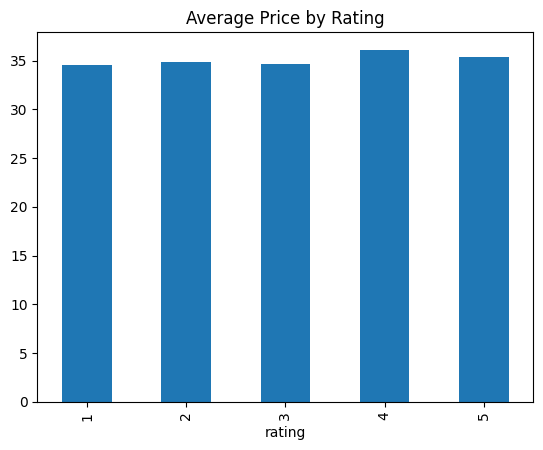

In [18]:
import matplotlib.pyplot as plt

df.groupby("rating")["price"].mean().plot(kind="bar")
plt.title("Average Price by Rating")
plt.show()

In [19]:
df.to_csv("books_analysis.csv", index=False)  # сохраняем итоговый датасет в CSV файл

## Основные выводы


- Распределение рейтингов книг достаточно равномерное, однако чаще всего встречаются книги с рейтингом **1 звезда**, а реже всего — с рейтингом **4 звезды**.
- Средняя цена книги составляет примерно **£35**
- **Рейтинг книги не оказывает значительного влияния на её цену**